# 03 — Baseline Classifiers: Jin et al. Per-Participant 80/20 Split

This notebook replicates the split strategy from **Jin et al. (2025)**: for each participant, take the first 80% of their windows for training and the last 20% for testing, then combine across all participants.

**Important caveat — block-design experiment structure:**

This dataset uses a strict sequential block design per participant:
```
WM-1 → WM-2 → WM-3 → VA-1 → VA-2 → VA-3 → Rest
```
A raw 80/20 temporal cut per participant puts the entire Rest block into the test set and leaves NO WM windows in the test set — both binary tasks break (training or test would contain only one class). Jin et al.'s 'temporal 80/20 per participant' is therefore interpreted as a **label-stratified temporal split**: for each label within each participant, the first 80% of that label's windows go to train and the last 20% go to test. This preserves temporal ordering within each task block while guaranteeing all labels appear in both splits.

**Why this differs from `02_baselines.ipynb` (global 80/20):**
The global split sorts all 347k windows together and cuts at 80% — the cut falls in the middle of the last participant's windows. The Jin split guarantees every participant **and** every cognitive state each contribute exactly 80% to training and 20% to test.

**Models:** SVM, Random Forest, KNN, XGBoost
**Tasks:** Rest vs Load | WM vs VA
**Target:** SVM ~62.3% accuracy on WM vs VA (Jin et al., 2025)

## 1. Imports and Setup

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
RESULTS = Path('../results/jin_split')
RESULTS.mkdir(exist_ok=True)

print('All imports OK.')

All imports OK.


## 2. Load Data

In [2]:
with open('../data/features/features_512_511.pkl', 'rb') as f:
    df = pickle.load(f)

FEATURES = [
    'ipas', 'lhipas', 'fixation_nums', 'fixation_durations',
    'blink_rate', 'saccade_speeds', 'saccade_peak_speeds'
]

print('Dataset shape:', df.shape)
print('Participants:', sorted(df['participant'].unique()))

Dataset shape: (347196, 18)
Participants: ['p1', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17', 'p18', 'p19', 'p20', 'p21', 'p22', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9']


## 3. Label-Stratified Per-Participant 80/20 Split

For each participant and each label, we sort that label's windows by `window_index` and take the first 80% as train, last 20% as test. All slices are then concatenated into a global train and test set.

This is the only interpretation of Jin et al.'s split that works with this block-design experiment — a pure temporal cut would leave entire cognitive states out of training or test.

In [3]:
train_parts, test_parts = [], []

for pid, p_group in df.groupby('participant'):
    for lbl, l_group in p_group.groupby('label'):
        l_sorted = l_group.sort_values('window_index')
        cut = int(len(l_sorted) * 0.8)
        train_parts.append(l_sorted.iloc[:cut])
        test_parts.append(l_sorted.iloc[cut:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

print(f'Train windows: {len(train_df):,}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Test  windows: {len(test_df):,}  ({len(test_df)/len(df)*100:.1f}%)')
print()
print('Train label distribution:', train_df['label'].value_counts().sort_index().to_dict())
print('Test  label distribution:', test_df['label'].value_counts().sort_index().to_dict())

Train windows: 277,704  (80.0%)
Test  windows: 69,492  (20.0%)

Train label distribution: {0: 18008, 1: 43305, 2: 43274, 3: 43281, 4: 43285, 5: 43273, 6: 43278}
Test  label distribution: {0: 4511, 1: 10835, 2: 10830, 3: 10830, 4: 10831, 5: 10824, 6: 10831}


## 4. Prepare Task Datasets

Same binary remapping as in all other notebooks:
- **Task 1 — Rest vs Load**: label 0 → Rest (0), labels 1–6 → Load (1)
- **Task 2 — WM vs VA**: labels 1–3 → WM (0), labels 4–6 → VA (1), rest excluded

`StandardScaler` fitted on train only — no leakage.

In [4]:
def make_task(train, test, task):
    if task == 'rest_vs_load':
        tr, te = train.copy(), test.copy()
        y_tr = (tr['label'] != 0).astype(int)
        y_te = (te['label'] != 0).astype(int)
    elif task == 'wm_vs_va':
        tr = train[train['label'] != 0].copy()
        te = test[test['label'] != 0].copy()
        y_tr = (tr['label'] > 3).astype(int)
        y_te = (te['label'] > 3).astype(int)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[FEATURES])
    X_te = scaler.transform(te[FEATURES])
    return X_tr, y_tr.values, X_te, y_te.values

X_tr1, y_tr1, X_te1, y_te1 = make_task(train_df, test_df, 'rest_vs_load')
X_tr2, y_tr2, X_te2, y_te2 = make_task(train_df, test_df, 'wm_vs_va')

print('Task 1 — Rest vs Load')
print(f'  Train: {X_tr1.shape},  class balance (Rest/Load): {np.bincount(y_tr1)}')
print(f'  Test : {X_te1.shape},  class balance (Rest/Load): {np.bincount(y_te1)}')
print()
print('Task 2 — WM vs VA (rest excluded)')
print(f'  Train: {X_tr2.shape},  class balance (WM/VA): {np.bincount(y_tr2)}')
print(f'  Test : {X_te2.shape},  class balance (WM/VA): {np.bincount(y_te2)}')

Task 1 — Rest vs Load
  Train: (277704, 7),  class balance (Rest/Load): [ 18008 259696]
  Test : (69492, 7),  class balance (Rest/Load): [ 4511 64981]

Task 2 — WM vs VA (rest excluded)
  Train: (259696, 7),  class balance (WM/VA): [129860 129836]
  Test : (64981, 7),  class balance (WM/VA): [32495 32486]


## 5. Define Models and Evaluation Helpers

Identical configurations to all other notebooks — the only variable is the split strategy.

In [5]:
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=5000, class_weight='balanced', n_jobs=-1, random_state=42),
        'SVM':           LinearSVC(C=1.0, max_iter=3000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
        'KNN':           KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
        'XGBoost':       XGBClassifier(n_estimators=200, n_jobs=-1, eval_metric='logloss',
                                       random_state=42, verbosity=0),
    }

def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'recall':    round(recall_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'f1':        round(f1_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'y_pred':    y_pred,
    }

print('Model definitions ready.')

Model definitions ready.


## 6. Task 1 — Rest vs Load

In [6]:
print('Training Task 1 — Rest vs Load ...')
results_t1 = {}
for name, model in get_models().items():
    print(f'  {name} ...', end=' ', flush=True)
    results_t1[name] = evaluate(model, X_tr1, y_tr1, X_te1, y_te1)
    print(f"acc={results_t1[name]['accuracy']:.4f}")

rows = [{'Model': n, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
         'Recall': r['recall'], 'F1': r['f1']} for n, r in results_t1.items()]
df_t1 = pd.DataFrame(rows).set_index('Model')
print('\nTask 1 Results:')
df_t1

Training Task 1 — Rest vs Load ...
  Logistic Regression ... 

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


acc=0.9981
  SVM ... acc=0.9963
  Random Forest ... acc=0.9947
  KNN ... acc=0.9952
  XGBoost ... acc=0.9972

Task 1 Results:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9981,0.9980,1.0,0.9990
SVM,0.9963,0.9961,1.0,0.9980
Random Forest,0.9947,0.9943,1.0,0.9972
KNN,0.9952,0.9949,1.0,0.9975
XGBoost,0.9972,0.9970,1.0,0.9985


### Confusion Matrices — Task 1 (Jin Split)

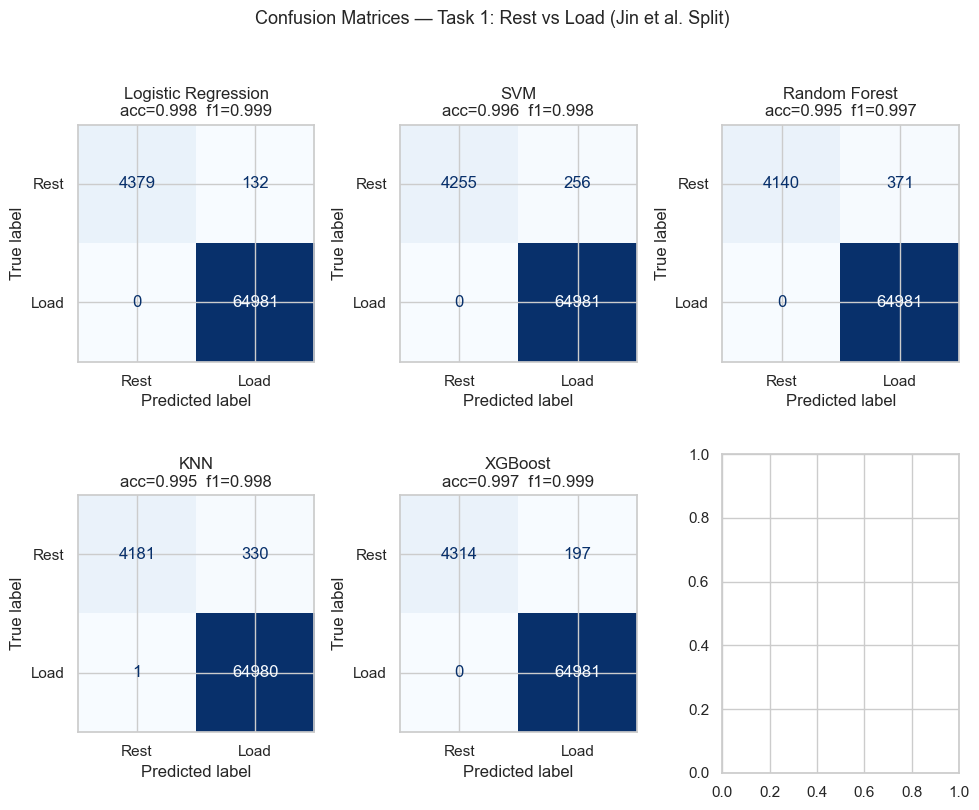

Saved: results/jin_confusion_matrix_rest_vs_load.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
for ax, (name, r) in zip(axes.flatten(), results_t1.items()):
    cm = confusion_matrix(y_te1, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Rest', 'Load']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nacc={r['accuracy']:.3f}  f1={r['f1']:.3f}")

plt.suptitle('Confusion Matrices — Task 1: Rest vs Load (Jin et al. Split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'jin_confusion_matrix_rest_vs_load.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/jin_split/jin_confusion_matrix_rest_vs_load.png')

## 7. Task 2 — WM vs VA

Primary benchmark task. Jin et al. (2025) report **SVM 62.3% accuracy** using this split strategy.

In [8]:
print('Training Task 2 — WM vs VA ...')
results_t2 = {}
for name, model in get_models().items():
    print(f'  {name} ...', end=' ', flush=True)
    results_t2[name] = evaluate(model, X_tr2, y_tr2, X_te2, y_te2)
    print(f"acc={results_t2[name]['accuracy']:.4f}")

rows = [{'Model': n, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
         'Recall': r['recall'], 'F1': r['f1']} for n, r in results_t2.items()]
df_t2 = pd.DataFrame(rows).set_index('Model')
print('\nTask 2 Results:')
df_t2

Training Task 2 — WM vs VA ...
  Logistic Regression ... 

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


acc=0.7225
  SVM ... acc=0.7162
  Random Forest ... acc=0.7956
  KNN ... acc=0.7370
  XGBoost ... acc=0.7986

Task 2 Results:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.7225,0.6771,0.8505,0.7539
SVM,0.7162,0.6731,0.8405,0.7475
Random Forest,0.7956,0.7457,0.8969,0.8143
KNN,0.7370,0.7045,0.8164,0.7563
XGBoost,0.7986,0.7609,0.8707,0.8121


### Confusion Matrices — Task 2 (Jin Split)

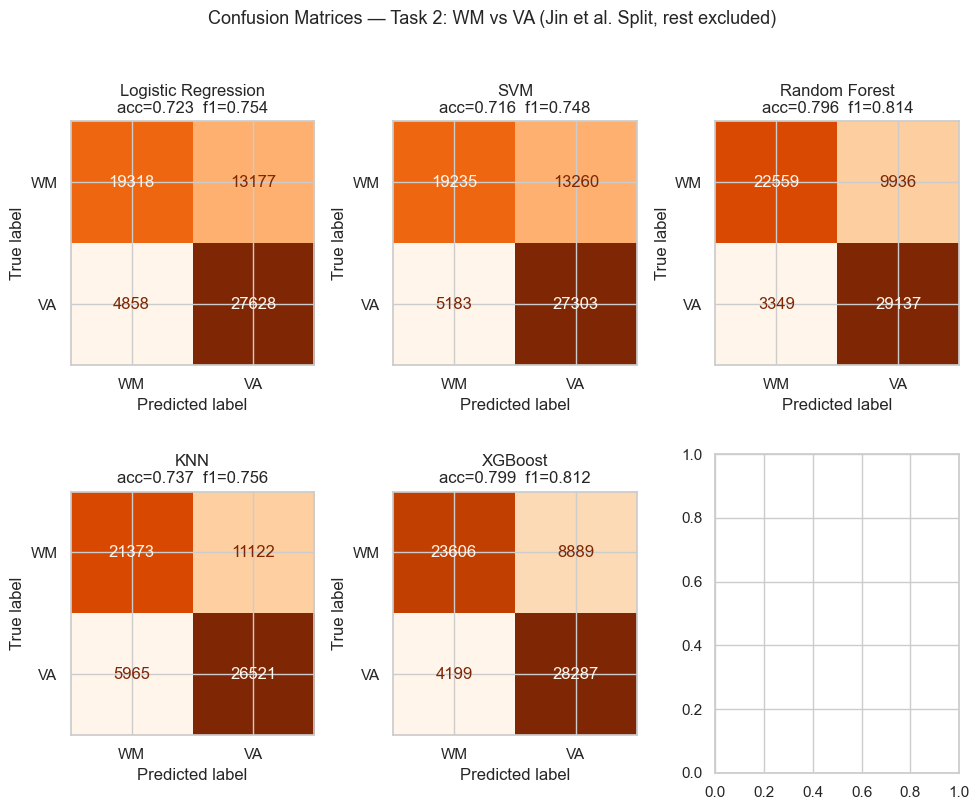

Saved: results/jin_confusion_matrix_wm_vs_va.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
for ax, (name, r) in zip(axes.flatten(), results_t2.items()):
    cm = confusion_matrix(y_te2, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['WM', 'VA']).plot(
        ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f"{name}\nacc={r['accuracy']:.3f}  f1={r['f1']:.3f}")

plt.suptitle('Confusion Matrices — Task 2: WM vs VA (Jin et al. Split, rest excluded)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'jin_confusion_matrix_wm_vs_va.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/jin_split/jin_confusion_matrix_wm_vs_va.png')

## 8. Summary and Comparison with Jin et al. (2025)

In [ ]:
rows_all = []
for task_name, results in [('Rest vs Load', results_t1), ('WM vs VA', results_t2)]:
    for model_name, r in results.items():
        rows_all.append({
            'Task': task_name, 'Model': model_name,
            'Accuracy': r['accuracy'], 'Precision': r['precision'],
            'Recall': r['recall'], 'F1': r['f1'],
        })

df_jin = pd.DataFrame(rows_all)
df_jin.to_csv(RESULTS / 'jin_split_results.csv', index=False)
print('Saved: results/jin_split/jin_split_results.csv\n')
print(df_jin.to_string(index=False))

svm_t2 = results_t2['SVM']['accuracy']
print(f'\nSVM accuracy on WM vs VA (Jin split): {svm_t2*100:.1f}%')
print(f'Jin et al. (2025) reported:            ~62.3%')
print(f'Difference:                            {svm_t2*100 - 62.3:+.1f} pp')

Saved: results/jin_split_results.csv

        Task               Model  Accuracy  Precision  Recall     F1
Rest vs Load Logistic Regression    0.9981     0.9980  1.0000 0.9990
Rest vs Load                 SVM    0.9963     0.9961  1.0000 0.9980
Rest vs Load       Random Forest    0.9947     0.9943  1.0000 0.9972
Rest vs Load                 KNN    0.9952     0.9949  1.0000 0.9975
Rest vs Load             XGBoost    0.9972     0.9970  1.0000 0.9985
    WM vs VA Logistic Regression    0.7225     0.6771  0.8505 0.7539
    WM vs VA                 SVM    0.7162     0.6731  0.8405 0.7475
    WM vs VA       Random Forest    0.7956     0.7457  0.8969 0.8143
    WM vs VA                 KNN    0.7370     0.7045  0.8164 0.7563
    WM vs VA             XGBoost    0.7986     0.7609  0.8707 0.8121

SVM accuracy on WM vs VA (Jin split): 71.6%
Jin et al. (2025) reported:            ~62.3%
Difference:                            +9.3 pp


## Summary

- **Split strategy**: label-stratified per-participant 80/20 (first 80% of each label's windows per participant → train; last 20% → test).
- Every participant and every cognitive state contributes exactly 80% / 20% to train / test.
- Results saved to `results/jin_split/jin_split_results.csv`.
- Confusion matrices: `results/jin_split/jin_confusion_matrix_rest_vs_load.png` and `results/jin_split/jin_confusion_matrix_wm_vs_va.png`.
- SVM WM vs VA accuracy compared directly against Jin et al. (2025) benchmark of 62.3%.